# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('punkt_tab')

print('Libraries imported successfully!')

Libraries imported successfully!


[nltk_data] Downloading package stopwords to /home/andri/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/andri/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /home/andri/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/andri/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [3]:
dataset_path = "../ASAP2_train_sourcetexts.csv"
df = pd.read_csv(dataset_path)
print(f'Dataset shape: {df.shape}')

df.head()

Dataset shape: (24728, 14)


,essay_id,score,full_text,assignment,prompt_name,economically_disadvantaged,student_disability_status,ell_status,race_ethnicity,gender,source_text_1,source_text_2,source_text_3,source_text_4
0,AAAVUP14319000159574,4,The author suggests that studying Venus is wor...,"In ""The Challenge of Exploring Venus,"" the aut...",Exploring Venus,Economically disadvantaged,Identified as having disability,No,Black/African American,F,"The Challenge of Exploring Venus\nVenus, somet...",NaN,NaN,NaN
1,AAAVUP14319000159542,2,NASA is fighting to be alble to to go to Venus...,"In ""The Challenge of Exploring Venus,"" the aut...",Exploring Venus,Not economically disadvantaged,Not identified as having disability,No,Hispanic/Latino,F,"The Challenge of Exploring Venus\nVenus, somet...",NaN,NaN,NaN
2,AAAVUP14319000159461,3,"""The Evening Star"", is one of the brightest po...","In ""The Challenge of Exploring Venus,"" the aut...",Exploring Venus,Economically disadvantaged,Identified as having disability,No,White,M,"The Challenge of Exploring Venus\nVenus, somet...",NaN,NaN,NaN
3,AAAVUP14319000159420,2,The author supports this idea because from rea...,"In ""The Challenge of Exploring Venus,"" the aut...",Exploring Venus,Economically disadvantaged,Not identified as having disability,Yes,Hispanic/Latino,F,"The Challenge of Exploring Venus\nVenus, somet...",NaN,NaN,NaN
4,AAAVUP14319000159419,2,How the author supports this idea is that he s...,"In ""The Challenge of Exploring Venus,"" the aut...",Exploring Venus,Economically disadvantaged,Not identified as having disability,Yes,Hispanic/Latino,M,"The Challenge of Exploring Venus\nVenus, somet...",NaN,NaN,NaN


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 24728 entries, 0 to 24727
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   essay_id                    24728 non-null  str  
 1   score                       24728 non-null  int64
 2   full_text                   24728 non-null  str  
 3   assignment                  24728 non-null  str  
 4   prompt_name                 24728 non-null  str  
 5   economically_disadvantaged  20723 non-null  str  
 6   student_disability_status   20723 non-null  str  
 7   ell_status                  24286 non-null  str  
 8   race_ethnicity              24724 non-null  str  
 9   gender                      24728 non-null  str  
 10  source_text_1               24728 non-null  str  
 11  source_text_2               4005 non-null   str  
 12  source_text_3               4005 non-null   str  
 13  source_text_4               1959 non-null   str  
dtypes: int64(1), str(

In [6]:
df.describe(include='all')

,essay_id,score,full_text,assignment,prompt_name,economically_disadvantaged,student_disability_status,ell_status,race_ethnicity,gender,source_text_1,source_text_2,source_text_3,source_text_4
count,24728,24728.000000,24728,24728,24728,20723,20723,24286,24724,24728,24728,4005,4005,1959
unique,24728,NaN,24728,7,7,2,2,2,6,2,7,2,2,1
top,AAAVUP14319000159574,NaN,The author suggests that studying Venus is wor...,"In the article “Driverless Cars are Coming,” t...",Driverless cars,Economically disadvantaged,Not identified as having disability,No,White,M,Driverless Cars Are Coming \nCan you imagine a...,The Indefensible\nElectoral College: Why even\...,In Defense of the\nElectoral College: Five\nre...,The End of Car\nCulture\nby Elisabeth Rosentha...
freq,1,NaN,1,6170,6170,12786,17746,21010,9867,12516,6170,2046,2046,1959
mean,NaN,2.939987,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,1.035991,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,2.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,3.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,4.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

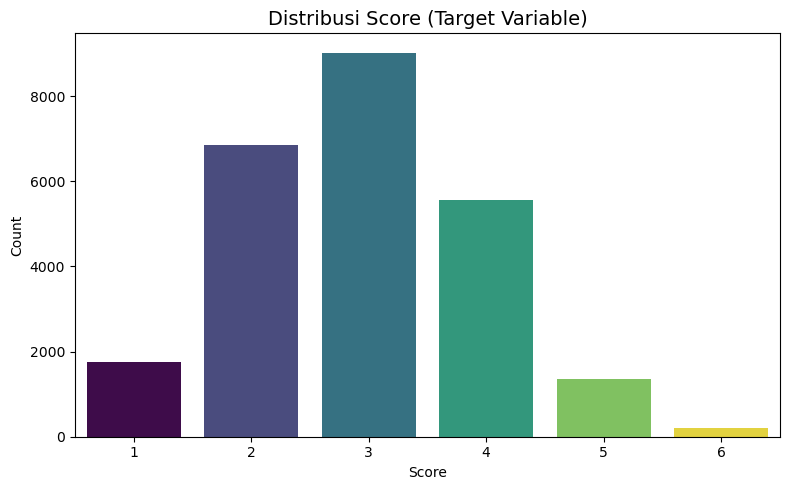

score
3    9021
2    6847
4    5553
1    1751
5    1356
6     200
Name: count, dtype: int64


In [7]:
# --- 3.1 Target Distribution ---
plt.figure(figsize=(8,5))
sns.countplot(x='score', data=df, palette='viridis', hue='score', legend=False)
plt.title('Distribusi Score (Target Variable)', fontsize=14)
plt.xlabel('Score')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('eda_score_distribution.png', dpi=100)
plt.show()
print(df['score'].value_counts())

In [8]:
# --- 3.2 Missing Values ---
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print('Missing Values per Column:')
print(missing_df[missing_df['Missing Count'] > 0])

Missing Values per Column:
                            Missing Count  Missing %
economically_disadvantaged           4005  16.196215
student_disability_status            4005  16.196215
ell_status                            442   1.787447
race_ethnicity                          4   0.016176
source_text_2                       20723  83.803785
source_text_3                       20723  83.803785
source_text_4                       22769  92.077807


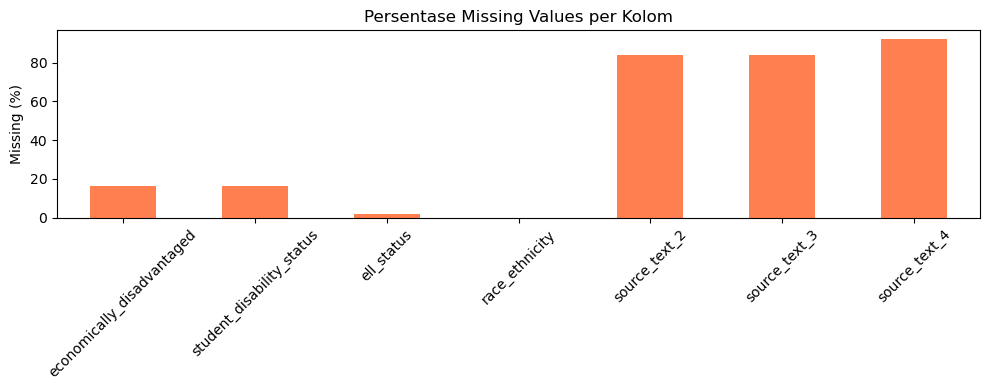

In [9]:
# --- 3.3 Visualize Missing Values ---
cols_with_missing = missing_df[missing_df['Missing Count'] > 0].index.tolist()
if cols_with_missing:
    plt.figure(figsize=(10, 4))
    missing_df[missing_df['Missing Count'] > 0]['Missing %'].plot(kind='bar', color='coral')
    plt.title('Persentase Missing Values per Kolom')
    plt.ylabel('Missing (%)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('eda_missing_values.png', dpi=100)
    plt.show()

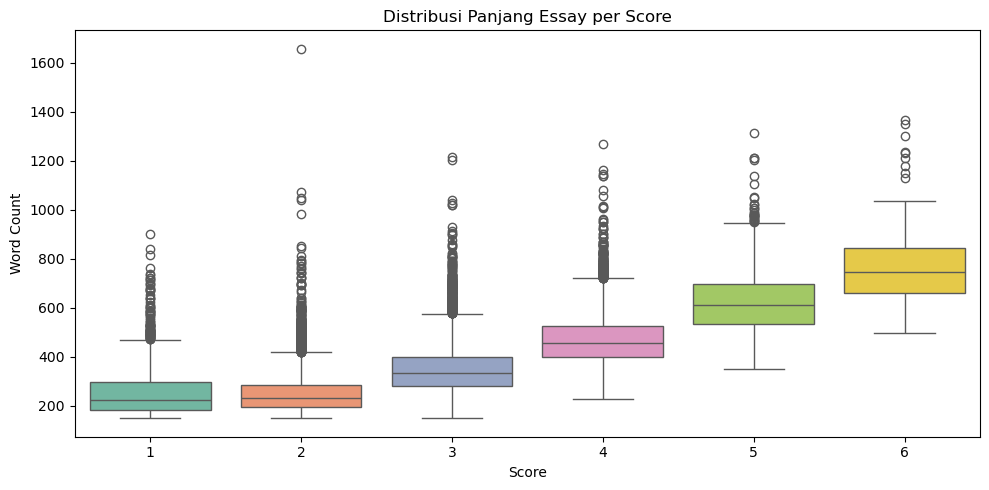

        count        mean         std    min     25%    50%     75%     max
score                                                                      
1      1751.0  257.932610  104.214109  150.0  184.00  225.0  299.50   902.0
2      6847.0  253.259092   87.251577  150.0  195.00  232.0  285.00  1656.0
3      9021.0  350.013746   98.490574  151.0  282.00  335.0  400.00  1213.0
4      5553.0  473.260220  105.703155  228.0  399.00  458.0  528.00  1268.0
5      1356.0  625.808260  127.518317  349.0  534.00  610.0  698.00  1312.0
6       200.0  769.675000  154.718546  497.0  660.75  747.0  844.25  1367.0


In [10]:
# --- 3.4 Essay Length Analysis ---
df['essay_length'] = df['full_text'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 5))
sns.boxplot(x='score', y='essay_length', data=df, palette='Set2', hue='score', legend=False)
plt.title('Distribusi Panjang Essay per Score')
plt.xlabel('Score')
plt.ylabel('Word Count')
plt.tight_layout()
plt.savefig('eda_essay_length_per_score.png', dpi=100)
plt.show()

print(df.groupby('score')['essay_length'].describe())

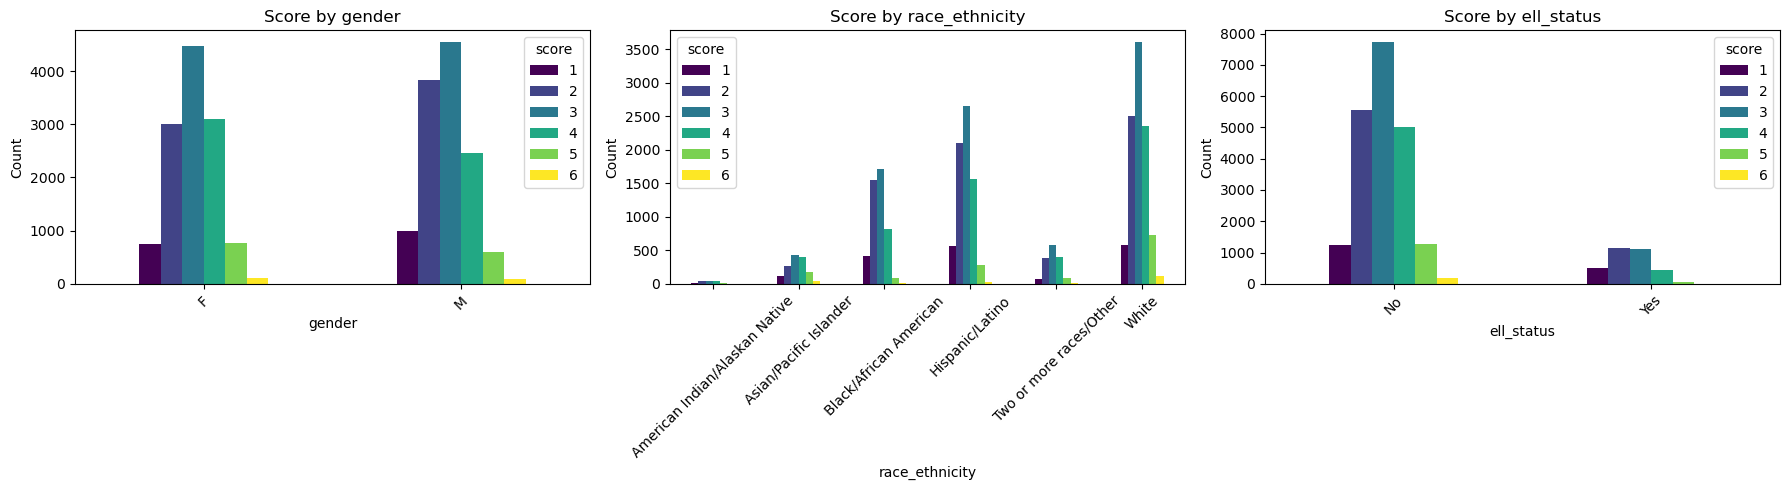

In [11]:
# --- 3.5 Distribution by Demographic Features ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

demo_cols = ['gender', 'race_ethnicity', 'ell_status']
for i, col in enumerate(demo_cols):
    score_demo = df.groupby([col, 'score']).size().unstack(fill_value=0)
    score_demo.plot(kind='bar', ax=axes[i], colormap='viridis')
    axes[i].set_title(f'Score by {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('eda_demographic_distribution.png', dpi=100)
plt.show()

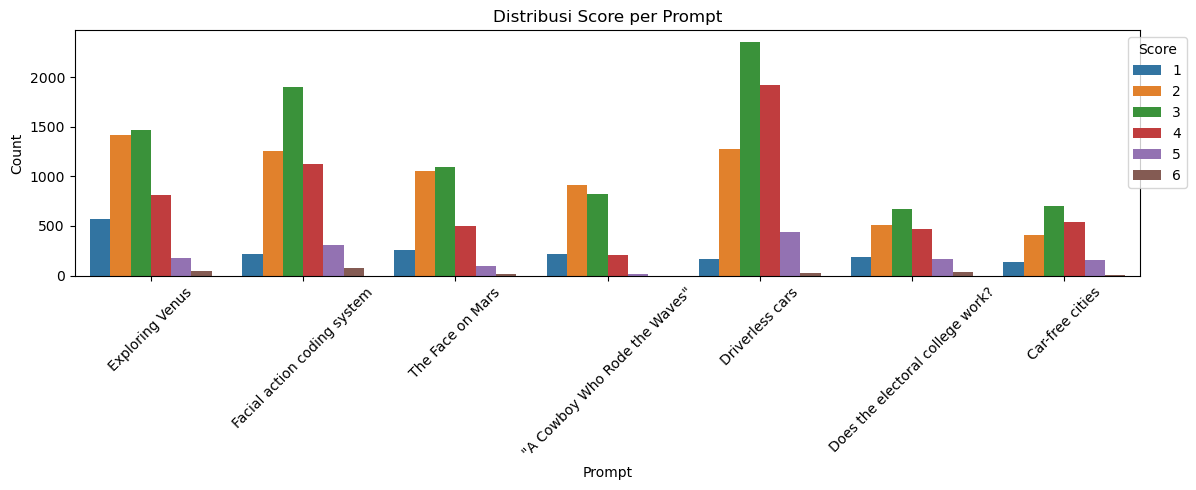

In [12]:
# --- 3.6 Score Distribution per Prompt ---
plt.figure(figsize=(12, 5))
sns.countplot(x='prompt_name', hue='score', data=df, palette='tab10')
plt.title('Distribusi Score per Prompt')
plt.xlabel('Prompt')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Score', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.savefig('eda_score_per_prompt.png', dpi=100)
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [13]:
# --- 4.1 Handle Missing Values ---
print('Before handling missing values:')
print(df.isnull().sum())

# Fill missing categorical columns with 'Unknown'
cat_cols_with_na = ['economically_disadvantaged', 'student_disability_status', 'ell_status', 'race_ethnicity']
for col in cat_cols_with_na:
    if col in df.columns:
        df[col] = df[col].fillna('Unknown')

# Drop source_text columns (high missing, not used in modeling)
source_cols = [c for c in df.columns if 'source_text' in c]
df.drop(columns=source_cols, inplace=True)

print('\nAfter handling missing values:')
print(df.isnull().sum())

Before handling missing values:
essay_id                          0
score                             0
full_text                         0
assignment                        0
prompt_name                       0
economically_disadvantaged     4005
student_disability_status      4005
ell_status                      442
race_ethnicity                    4
gender                            0
source_text_1                     0
source_text_2                 20723
source_text_3                 20723
source_text_4                 22769
essay_length                      0
dtype: int64

After handling missing values:
essay_id                      0
score                         0
full_text                     0
assignment                    0
prompt_name                   0
economically_disadvantaged    0
student_disability_status     0
ell_status                    0
race_ethnicity                0
gender                        0
essay_length                  0
dtype: int64


In [14]:
# --- 4.2 Text Cleaning Function ---
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    """Membersihkan teks essay"""
    if pd.isna(text):
        return ''
    # Lowercase
    text = text.lower()
    # Remove special characters & numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Tokenize
    tokens = word_tokenize(text)
    # Remove stopwords & lemmatize
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words and len(w) > 2]
    return ' '.join(tokens)

# Apply text cleaning
print('Cleaning text...')
df['processed_text'] = df['full_text'].apply(clean_text)
print('Text cleaning done!')
df[['full_text', 'processed_text']].head(3)

Cleaning text...
Text cleaning done!


,full_text,processed_text
0,The author suggests that studying Venus is wor...,author suggests studying venus worthy enough e...
1,NASA is fighting to be alble to to go to Venus...,nasa fighting alble venus researching diffrent...
2,"""The Evening Star"", is one of the brightest po...",evening star one brightest point light sky nig...


In [15]:
# --- 4.3 Feature Engineering ---
# Add text-based features
df['word_count'] = df['full_text'].apply(lambda x: len(str(x).split()))
df['char_count'] = df['full_text'].apply(lambda x: len(str(x)))
df['avg_word_length'] = df['char_count'] / (df['word_count'] + 1)
df['sentence_count'] = df['full_text'].apply(lambda x: len(re.split(r'[.!?]+', str(x))))
df['unique_word_ratio'] = df['full_text'].apply(lambda x: len(set(str(x).lower().split())) / (len(str(x).split()) + 1))

print('Feature engineering done!')
print(df[['word_count', 'char_count', 'avg_word_length', 'sentence_count', 'unique_word_ratio']].describe())

Feature engineering done!
         word_count    char_count  avg_word_length  sentence_count  \
count  24728.000000  24728.000000     24728.000000    24728.000000   
mean     362.897282   2035.663499         5.584935       20.546627   
std      148.461603    900.741907         1.203720        8.747729   
min      150.000000    697.000000         4.352217        1.000000   
25%      249.000000   1376.000000         5.321965       14.000000   
50%      338.000000   1881.000000         5.539735       19.000000   
75%      446.000000   2501.000000         5.762983       26.000000   
max     1656.000000  20459.000000        78.688462      136.000000   

       unique_word_ratio  
count       24728.000000  
mean            0.513437  
std             0.073337  
min             0.054919  
25%             0.462232  
50%             0.511685  
75%             0.563107  
max             0.777778  


In [16]:
# --- 4.4 Encode Categorical Features ---
cat_features = ['gender', 'race_ethnicity', 'economically_disadvantaged', 
                'student_disability_status', 'ell_status', 'prompt_name']

le = LabelEncoder()
for col in cat_features:
    if col in df.columns:
        df[f'{col}_encoded'] = le.fit_transform(df[col].astype(str))
        print(f'Encoded: {col} -> {col}_encoded')

Encoded: gender -> gender_encoded
Encoded: race_ethnicity -> race_ethnicity_encoded
Encoded: economically_disadvantaged -> economically_disadvantaged_encoded
Encoded: student_disability_status -> student_disability_status_encoded
Encoded: ell_status -> ell_status_encoded
Encoded: prompt_name -> prompt_name_encoded


In [18]:
# --- 4.5 Create Score Label ---
# Map score to label
df['score_label'] = df['score'].astype(str)
print('Score distribution:')
print(df['score_label'].value_counts())

Score distribution:
score_label
3    9021
2    6847
4    5553
1    1751
5    1356
6     200
Name: count, dtype: int64


In [20]:
# --- 4.6 Select Final Columns for Preprocessing Output ---
final_cols = [
    'essay_id', 'score', 'score_label',
    'processed_text',
    'word_count', 'char_count', 'avg_word_length', 'sentence_count', 'unique_word_ratio',
    'gender_encoded', 'race_ethnicity_encoded', 'economically_disadvantaged_encoded',
    'student_disability_status_encoded', 'ell_status_encoded', 'prompt_name_encoded'
]

df_preprocessed = df[final_cols].copy()
print(f'Final preprocessed shape: {df_preprocessed.shape}')
df_preprocessed.head()

Final preprocessed shape: (24728, 15)


,essay_id,score,score_label,processed_text,word_count,char_count,avg_word_length,sentence_count,unique_word_ratio,gender_encoded,race_ethnicity_encoded,economically_disadvantaged_encoded,student_disability_status_encoded,ell_status_encoded,prompt_name_encoded
0,AAAVUP14319000159574,4,4,author suggests studying venus worthy enough e...,396,2346,5.909320,18,0.549118,0,2,0,0,0,4
1,AAAVUP14319000159542,2,2,nasa fighting alble venus researching diffrent...,200,1019,5.069652,13,0.587065,0,3,1,1,0,4
2,AAAVUP14319000159461,3,3,evening star one brightest point light sky nig...,371,2156,5.795699,32,0.551075,1,6,0,0,0,4
3,AAAVUP14319000159420,2,2,author support idea reading passage suggests v...,224,1251,5.560000,11,0.577778,0,3,0,1,2,4
4,AAAVUP14319000159419,2,2,author support idea state text strivivng meet ...,219,1231,5.595455,8,0.609091,1,3,0,1,2,4


In [21]:
# --- 4.7 Train/Test Split ---
X = df_preprocessed.drop(columns=['essay_id', 'score', 'score_label'])
y = df_preprocessed['score_label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train set: {X_train.shape}')
print(f'Test set:  {X_test.shape}')
print(f'Train label distribution:\n{y_train.value_counts()}')

Train set: (19782, 12)
Test set:  (4946, 12)
Train label distribution:
score_label
3    7217
2    5477
4    4442
1    1401
5    1085
6     160
Name: count, dtype: int64


In [22]:
# --- 4.8 Save Preprocessed Dataset ---
import os
os.makedirs('../preprocessing/asap2_preprocessing', exist_ok=True)

df_preprocessed.to_csv('../preprocessing/asap2_preprocessing/asap2_preprocessed.csv', index=False)

# Save train/test split
train_df = X_train.copy()
train_df['score_label'] = y_train
test_df = X_test.copy()
test_df['score_label'] = y_test

train_df.to_csv('../preprocessing/asap2_preprocessing/train_preprocessed.csv', index=False)
test_df.to_csv('../preprocessing/asap2_preprocessing/test_preprocessed.csv', index=False)

print('Preprocessing output saved!')
print('Files:')
print('  - asap2_preprocessing/asap2_preprocessed.csv')
print('  - asap2_preprocessing/train_preprocessed.csv')
print('  - asap2_preprocessing/test_preprocessed.csv')

Preprocessing output saved!
Files:
  - asap2_preprocessing/asap2_preprocessed.csv
  - asap2_preprocessing/train_preprocessed.csv
  - asap2_preprocessing/test_preprocessed.csv
